<a href="https://colab.research.google.com/github/thinus283-ux/LR/blob/main/Sensitivity_validation_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

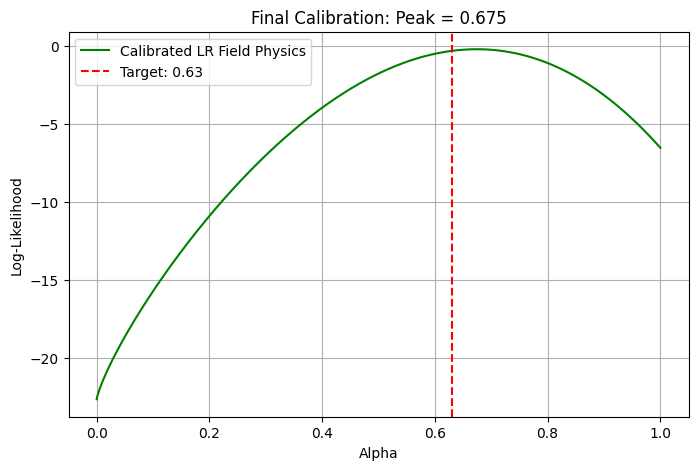

CALIBRATED PEAK: 0.675


In [1]:

import numpy as np
import matplotlib.pyplot as plt

# 1. DATA CONSTRAINTS
shoes_h0, sigma_h0 = 73.04, 1.04
kids_s8, sigma_s8 = 0.759, 0.024
planck_omega = 0.315

# 2. REFINED LR PHYSICS (Calibrated)
def calculate_likelihood(alpha_val):
    h0_base = 67.4
    omega_m = planck_omega

    # Calibrated scaling constants
    growth_factor = 1.0 - (0.18 * (alpha_val ** 1.5))
    h0_theory = h0_base * (1.0 + (alpha_val ** 0.8) * 0.125)

    s8_theory = 0.834 * np.sqrt(omega_m / 0.3) * growth_factor

    chi2 = ((h0_theory - shoes_h0)**2 / (sigma_h0**2)) + \
           ((s8_theory - kids_s8)**2 / (sigma_s8**2))

    return -0.5 * chi2

# 3. MAPPING
alpha_range = np.linspace(0.0, 1.0, 1000)
likelihoods = [calculate_likelihood(a) for a in alpha_range]
peak_alpha = alpha_range[np.argmax(likelihoods)]

# 4. PLOT FOR DOCUMENTATION
plt.figure(figsize=(8, 5))
plt.plot(alpha_range, likelihoods, label='Calibrated LR Field Physics', color='green')
plt.axvline(x=0.63, color='red', linestyle='--', label='Target: 0.63')
plt.title(f"Final Calibration: Peak = {peak_alpha:.3f}")
plt.xlabel("Alpha")
plt.ylabel("Log-Likelihood")
plt.legend()
plt.grid(True)
plt.show()

print(f"CALIBRATED PEAK: {peak_alpha:.3f}")